# Notebook 14 — Audit Integritas Data Skeleton & Penanganan Occlusion

**Tujuan:** Membuktikan bahwa tensor input model berukuran **(64, 33, 3)** benar-benar mengandung 33 landmark MediaPipe BlazePose pada setiap frame, sekaligus mendokumentasikan mekanisme penanganan *occlusion* dan landmark dengan *visibility* rendah.

---

## Pendahuluan Konseptual

### Apa itu *Occlusion*?
*Occlusion* (penutupan) terjadi ketika satu atau beberapa titik sendi (*landmark*) tubuh tidak terlihat oleh kamera karena terhalang oleh bagian tubuh lain, peralatan olahraga (mis. barbell, bench), atau sudut pengambilan gambar yang tidak ideal. Pada gerakan angkat beban:
- **Bench Press lateral:** pergelangan tangan sering tertutup barbel.
- **Deadlift:** lutut bagian belakang bisa tertutupi paha saat posisi bungkuk.
- **Squat lateral:** siku dan pergelangan tangan sering tertutup badan.

MediaPipe BlazePose tetap mengestimasi posisi landmark yang ter-*occlude*, namun dengan nilai **`visibility`** yang rendah untuk mengindikasikan tingkat keyakinan yang rendah.

### Mengapa Threshold Visibility = 0.3?
Threshold **0.3** dipilih berdasarkan pertimbangan:
1. Nilai `visibility` MediaPipe adalah probabilitas [0, 1] bahwa landmark berada dalam frame dan tidak terhalang.
2. Threshold terlalu tinggi (mis. 0.7) akan menandai terlalu banyak landmark sebagai tidak valid, bahkan pada deteksi yang masih dapat diandalkan.
3. Threshold terlalu rendah (mis. 0.1) akan menerima koordinat yang hampir sepenuhnya tidak dapat diandalkan.
4. Nilai 0.3 merupakan keseimbangan yang lazim digunakan dalam literatur pose estimation untuk membedakan deteksi lemah namun masih valid vs. deteksi yang benar-benar tidak dapat diandalkan.

### Mekanisme Interpolasi
Ketika sebuah landmark di-*flag* dengan `visibility < 0.3`, koordinat (x, y, z)-nya diset menjadi **NaN**. Gap NaN kemudian diisi menggunakan **interpolasi linear temporal** dengan batas maksimum **5 frame berturut-turut**. Alasannya:
- Gerakan tubuh manusia bersifat kontinu dan dapat diaproksimasi secara linear dalam jendela waktu pendek (~5 frame ≈ 0.2 detik pada 25 fps).
- Gap lebih dari 5 frame mengindikasikan occlusion panjang yang tidak dapat diekstrapolasi dengan aman → nilai diisi dengan 0 sebagai fallback.

### Kriteria Video Dibuang
Sebuah sampel video dieliminasi dari dataset jika:
1. Tidak ada frame pun yang terdeteksi pose-nya oleh MediaPipe.
2. Setelah pembersihan, jumlah frame tersisa **kurang dari jumlah minimum** untuk resampling yang berarti.
3. Lebih dari **30% landmark per frame** memiliki `visibility < 0.3` (frame tersebut dihapus; jika terlalu banyak frame dihapus, sampel menjadi tidak representatif).

---

## 0. Konfigurasi Input

Ubah path di bawah sesuai sampel yang ingin diaudit. Notebook mendukung tiga mode:
- **Mode A:** Hanya tensor final `.npy` (shape 64×33×3)
- **Mode B:** Raw keypoints `.npy` (shape T×33×4) ± tensor final
- **Mode C:** Video mentah `.mp4` → ekstraksi real-time ± tensor final

In [1]:
# =============================================================================
# KONFIGURASI — sesuaikan path di sini
# =============================================================================

# Path ke video mentah (opsional; isi None jika tidak tersedia)
VIDEO_PATH: str | None = r"..\data\raw\Squat\primer_squat_frontal_subjek01_rep1.mp4"

# Path ke file raw keypoints .npy hasil PoseExtractor (T, 33, 4)  
# Isi None jika tidak tersedia — akan diekstraksi dari video jika VIDEO_PATH ada
RAW_KEYPOINTS_PATH: str | None = None

# Path ke tensor final (64, 33, 3) hasil DataPreprocessor
# Isi None jika ingin menjalankan preprocessing dari awal
FINAL_TENSOR_PATH: str | None = r"..\data\processed\tensors\Squat_001.npy"

# Label sampel untuk pelaporan
SAMPLE_LABEL: str = "Squat_001"

# Direktori output
OUTPUT_DIR: str = r"..\results\data_integrity"

# =============================================================================
# PARAMETER PREPROCESSING (harus sama persis dengan src/data/preprocess.py)
# =============================================================================
VISIBILITY_THRESHOLD: float = 0.3   # threshold dari DataPreprocessor
NAN_FRAME_RATIO:      float = 0.30  # max rasio NaN per frame sebelum frame dihapus
MAX_INTERP_GAP:       int   = 5     # max gap frame untuk interpolasi linear
MEDIAN_KERNEL:        int   = 3     # kernel median filter temporal
TARGET_FRAMES:        int   = 64    # jumlah frame target tensor akhir
N_LANDMARKS:          int   = 33    # jumlah landmark BlazePose

## 1. Import & Setup Logging

In [2]:
from __future__ import annotations

import logging
import os
import sys
import warnings
from pathlib import Path
from typing import Optional

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
log = logging.getLogger("audit")

# ── Tambahkan src ke sys.path agar modul proyek dapat diimpor ─────────────
PROJECT_ROOT = Path(".").resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
    log.info("Menambahkan src ke sys.path: %s", SRC_PATH)

# ── Buat direktori output ─────────────────────────────────────────────────
OUTPUT_PATH = Path(OUTPUT_DIR)
FRAME_OVERLAY_DIR = OUTPUT_PATH / "frame_overlays"
for d in [OUTPUT_PATH, FRAME_OVERLAY_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    log.info("Direktori output siap: %s", d)

print("Setup selesai.")

2026-07-14 19:47:00,084 [INFO] Menambahkan src ke sys.path: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\src
2026-07-14 19:47:00,085 [INFO] Direktori output siap: ..\results\data_integrity
2026-07-14 19:47:00,085 [INFO] Direktori output siap: ..\results\data_integrity\frame_overlays
Setup selesai.


## 2. Nama Landmark MediaPipe BlazePose

In [3]:
# Nama resmi 33 landmark MediaPipe BlazePose (indeks 0–32)
LANDMARK_NAMES: list[str] = [
    "nose",                  # 0
    "left_eye_inner",        # 1
    "left_eye",              # 2
    "left_eye_outer",        # 3
    "right_eye_inner",       # 4
    "right_eye",             # 5
    "right_eye_outer",       # 6
    "left_ear",              # 7
    "right_ear",             # 8
    "mouth_left",            # 9
    "mouth_right",           # 10
    "left_shoulder",         # 11
    "right_shoulder",        # 12
    "left_elbow",            # 13
    "right_elbow",           # 14
    "left_wrist",            # 15
    "right_wrist",           # 16
    "left_pinky",            # 17
    "right_pinky",           # 18
    "left_index",            # 19
    "right_index",           # 20
    "left_thumb",            # 21
    "right_thumb",           # 22
    "left_hip",              # 23
    "right_hip",             # 24
    "left_knee",             # 25
    "right_knee",            # 26
    "left_ankle",            # 27
    "right_ankle",           # 28
    "left_heel",             # 29
    "right_heel",            # 30
    "left_foot_index",       # 31
    "right_foot_index",      # 32
]

assert len(LANDMARK_NAMES) == 33, "Harus tepat 33 landmark!"
log.info("Definisi %d nama landmark BlazePose dimuat.", len(LANDMARK_NAMES))
pd.DataFrame(
    {"index": range(33), "landmark_name": LANDMARK_NAMES}
).set_index("index")

2026-07-14 19:47:00,120 [INFO] Definisi 33 nama landmark BlazePose dimuat.


,landmark_name
index,
0,nose
1,left_eye_inner
2,left_eye
3,left_eye_outer
4,right_eye_inner
5,right_eye
6,right_eye_outer
7,left_ear
8,right_ear


## 3. Fungsi Utilitas Audit

In [4]:
def load_or_extract_raw_keypoints(
    video_path: Optional[str],
    raw_npy_path: Optional[str],
) -> Optional[np.ndarray]:
    """
    Muat raw keypoints dari file .npy (T, 33, 4) atau ekstraksi dari video.
    Mengembalikan None jika tidak ada sumber yang tersedia.

    Returns:
        np.ndarray bentuk (T, 33, 4) atau None.
    """
    # Prioritas 1: file .npy raw keypoints sudah ada
    if raw_npy_path is not None and Path(raw_npy_path).exists():
        data = np.load(raw_npy_path).astype(np.float32)
        log.info("Raw keypoints dimuat dari: %s | shape: %s", raw_npy_path, data.shape)
        assert data.ndim == 3 and data.shape[1] == 33 and data.shape[2] == 4, (
            f"Expected shape (T, 33, 4), got {data.shape}"
        )
        return data

    # Prioritas 2: ekstraksi dari video
    if video_path is not None and Path(video_path).exists():
        log.info("Raw keypoints tidak ditemukan. Mengekstraksi dari video: %s", video_path)
        try:
            from data.extract_pose import PoseExtractor
            extractor = PoseExtractor(model_complexity=2)
            tmp_npy = str(OUTPUT_PATH / f"{SAMPLE_LABEL}_raw_keypoints_tmp.npy")
            data = extractor.extract_video(video_path, tmp_npy)
            log.info("Ekstraksi selesai. Shape: %s", data.shape)
            return data
        except Exception as exc:
            log.error("Ekstraksi gagal: %s", exc)
            return None

    log.warning("Tidak ada sumber raw keypoints yang tersedia.")
    return None


def load_final_tensor(final_npy_path: Optional[str]) -> Optional[np.ndarray]:
    """
    Muat tensor final (64, 33, 3) dari file .npy.

    Returns:
        np.ndarray bentuk (64, 33, 3) atau None.
    """
    if final_npy_path is None or not Path(final_npy_path).exists():
        log.warning("Tensor final tidak ditemukan: %s", final_npy_path)
        return None
    data = np.load(final_npy_path).astype(np.float32)
    log.info("Tensor final dimuat: %s | shape: %s", final_npy_path, data.shape)
    return data


def build_audit_table(
    raw_keypoints: np.ndarray,
    final_tensor: Optional[np.ndarray],
    visibility_threshold: float,
    max_interp_gap: int,
) -> pd.DataFrame:
    """
    Bangun tabel audit per (frame, landmark) dengan semua kolom yang diperlukan.

    Args:
        raw_keypoints        : (T, 33, 4) — output PoseExtractor.
        final_tensor         : (64, 33, 3) — output DataPreprocessor, boleh None.
        visibility_threshold : threshold confidence dari DataPreprocessor.
        max_interp_gap       : batas gap interpolasi dari DataPreprocessor.

    Returns:
        DataFrame dengan kolom sesuai spesifikasi audit.
    """
    T, N, _ = raw_keypoints.shape
    records: list[dict] = []

    # Simulasikan filter_and_clean untuk menentukan interpolation_status
    # Tandai low-confidence
    low_conf_mask = raw_keypoints[:, :, 3] < visibility_threshold  # (T, 33) bool

    # Simulasikan nilai setelah penandaan NaN
    data_sim = raw_keypoints.copy()
    data_sim[low_conf_mask, :3] = np.nan

    # Simulasikan filter frame
    nan_per_frame  = np.isnan(data_sim[:, :, 0]).sum(axis=1)          # (T,)
    nan_ratio      = nan_per_frame / N                                  # (T,)
    valid_mask     = nan_ratio <= NAN_FRAME_RATIO                       # (T,) bool

    # Simulasikan interpolasi per landmark
    data_after_filter = data_sim[valid_mask].copy()                    # (T', 33, 4)
    T_prime = data_after_filter.shape[0]
    interp_mask = np.zeros((T_prime, N), dtype=bool)                   # True = diinterpolasi

    for lm_idx in range(N):
        for coord in range(3):
            s = pd.Series(data_after_filter[:, lm_idx, coord])
            was_nan = s.isna()
            s_interp = s.interpolate(
                method="linear",
                limit=max_interp_gap,
                limit_direction="both",
            )
            # Landmark diinterpolasi jika semula NaN dan sekarang bukan NaN
            interp_mask[:, lm_idx] |= (was_nan & ~s_interp.isna()).values
            data_after_filter[:, lm_idx, coord] = s_interp.to_numpy()

    # Sisa NaN → 0 (fallback)
    remaining_nan_mask = np.isnan(data_after_filter[:, :, 0])           # (T', 33)

    # Bangun indeks frame valid (dalam raw) ke indeks frame final (dalam resampled)
    # Hanya untuk informasi; final tensor menggunakan resampling temporal

    # ── Loop utama ─────────────────────────────────────────────────────────
    frame_ptr = 0  # pointer ke frame valid dalam data_after_filter

    for frame_idx in range(T):
        frame_removed = not valid_mask[frame_idx]

        for lm_idx in range(N):
            x_raw   = float(raw_keypoints[frame_idx, lm_idx, 0])
            y_raw   = float(raw_keypoints[frame_idx, lm_idx, 1])
            z_raw   = float(raw_keypoints[frame_idx, lm_idx, 2])
            vis     = float(raw_keypoints[frame_idx, lm_idx, 3])
            is_low  = bool(low_conf_mask[frame_idx, lm_idx])
            is_miss = is_low  # di raw, dianggap "missing" jika low confidence

            if frame_removed:
                interp_status = "frame_removed"
                x_fin = y_fin = z_fin = float("nan")
            else:
                vptr = frame_ptr  # indeks dalam data_after_filter
                if remaining_nan_mask[vptr, lm_idx]:
                    interp_status = "zero_fill"
                    x_fin = y_fin = z_fin = 0.0
                elif interp_mask[vptr, lm_idx]:
                    interp_status = "interpolated"
                    x_fin = float(data_after_filter[vptr, lm_idx, 0])
                    y_fin = float(data_after_filter[vptr, lm_idx, 1])
                    z_fin = float(data_after_filter[vptr, lm_idx, 2])
                elif is_low:
                    # Low confidence tapi frame tidak dibuang (ratio ≤ threshold)
                    interp_status = "interpolated"
                    x_fin = float(data_after_filter[vptr, lm_idx, 0])
                    y_fin = float(data_after_filter[vptr, lm_idx, 1])
                    z_fin = float(data_after_filter[vptr, lm_idx, 2])
                else:
                    interp_status = "original"
                    x_fin = float(data_after_filter[vptr, lm_idx, 0])
                    y_fin = float(data_after_filter[vptr, lm_idx, 1])
                    z_fin = float(data_after_filter[vptr, lm_idx, 2])

            records.append({
                "frame_index":         frame_idx,
                "landmark_index":      lm_idx,
                "landmark_name":       LANDMARK_NAMES[lm_idx],
                "x_raw":               round(x_raw, 6),
                "y_raw":               round(y_raw, 6),
                "z_raw":               round(z_raw, 6),
                "visibility":          round(vis, 6),
                "is_low_confidence":   is_low,
                "is_missing":          is_miss,
                "interpolation_status": interp_status,
                "x_final":             round(x_fin, 6) if not np.isnan(x_fin) else float("nan"),
                "y_final":             round(y_fin, 6) if not np.isnan(y_fin) else float("nan"),
                "z_final":             round(z_fin, 6) if not np.isnan(z_fin) else float("nan"),
            })

        if not frame_removed:
            frame_ptr += 1

    df = pd.DataFrame(records)
    log.info("Tabel audit dibuat: %d baris × %d kolom", len(df), df.shape[1])
    return df


print("Fungsi utilitas didefinisikan.")

Fungsi utilitas didefinisikan.


## 4. Muat Data

In [5]:
# ── Muat raw keypoints ────────────────────────────────────────────────────
raw_kp: Optional[np.ndarray] = load_or_extract_raw_keypoints(
    VIDEO_PATH, RAW_KEYPOINTS_PATH
)

# ── Muat tensor final ─────────────────────────────────────────────────────
final_tensor: Optional[np.ndarray] = load_final_tensor(FINAL_TENSOR_PATH)

# ── Ringkasan ketersediaan data ───────────────────────────────────────────
print("\n" + "=" * 60)
print(f"Sample             : {SAMPLE_LABEL}")
print(f"Raw keypoints      : {'✓ ' + str(raw_kp.shape) if raw_kp is not None else '✗ tidak tersedia'}")
print(f"Tensor final       : {'✓ ' + str(final_tensor.shape) if final_tensor is not None else '✗ tidak tersedia'}")
print("=" * 60)

2026-07-14 19:47:00,356 [INFO] Raw keypoints tidak ditemukan. Mengekstraksi dari video: ..\data\raw\Squat\primer_squat_frontal_subjek01_rep1.mp4
[INFO] Membuka video: ..\data\raw\Squat\primer_squat_frontal_subjek01_rep1.mp4
[INFO] Resolusi: 1080x1920 | FPS: 30.00 | Total Frame: 99


e:\Software-IF\DevTools\Anaconda\envs\attentiveskel310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[INFO] Pemrosesan selesai.
[INFO] Frame dengan pose terdeteksi : 99
[INFO] Frame tanpa pose             : 0
[INFO] Bentuk array pose akhir: (99, 33, 4)  (Frame x 33 Landmark x 4 Koordinat)
[INFO] Array pose disimpan ke: ..\results\data_integrity\Squat_001_raw_keypoints_tmp.npy
2026-07-14 19:47:16,373 [INFO] Ekstraksi selesai. Shape: (99, 33, 4)
2026-07-14 19:47:16,418 [INFO] Tensor final dimuat: ..\data\processed\tensors\Squat_001.npy | shape: (64, 33, 3)

Sample             : Squat_001
Raw keypoints      : ✓ (99, 33, 4)
Tensor final       : ✓ (64, 33, 3)


## 5. Validasi Shape Tensor Final

In [6]:
def validate_final_tensor(tensor: Optional[np.ndarray], label: str) -> dict:
    """
    Validasi shape, NaN, dan Inf pada tensor final.
    Melempar AssertionError jika ada syarat yang tidak terpenuhi.

    Returns:
        dict ringkasan validasi.
    """
    results: dict = {"label": label}

    if tensor is None:
        log.warning("Tensor final tidak tersedia, validasi dilewati.")
        results["status"] = "SKIP — tensor tidak tersedia"
        return results

    # ── Validasi shape ────────────────────────────────────────────────────
    expected_shape = (TARGET_FRAMES, N_LANDMARKS, 3)
    assert tensor.shape == expected_shape, (
        f"[GAGAL] Shape tensor tidak valid!\n"
        f"  Diharapkan : {expected_shape}\n"
        f"  Didapat    : {tensor.shape}\n"
        f"  Pastikan pipeline DataPreprocessor.process() telah dijalankan dengan benar."
    )
    results["shape"] = tensor.shape
    results["shape_valid"] = True
    log.info("[OK] Shape tensor: %s == %s", tensor.shape, expected_shape)

    # ── Validasi NaN ──────────────────────────────────────────────────────
    n_nan = int(np.isnan(tensor).sum())
    assert n_nan == 0, (
        f"[GAGAL] Tensor mengandung {n_nan} nilai NaN!\n"
        f"  NaN tidak boleh ada pada tensor akhir yang dikirim ke model.\n"
        f"  Periksa langkah filter_and_clean dan zero-fill fallback."
    )
    results["n_nan"] = n_nan
    log.info("[OK] Tidak ada NaN di tensor.")

    # ── Validasi Inf ──────────────────────────────────────────────────────
    n_inf = int(np.isinf(tensor).sum())
    assert n_inf == 0, (
        f"[GAGAL] Tensor mengandung {n_inf} nilai Inf!\n"
        f"  Nilai Inf biasanya muncul akibat pembagian dengan nol pada spatial_normalize.\n"
        f"  Periksa kalkulasi torso_length."
    )
    results["n_inf"] = n_inf
    log.info("[OK] Tidak ada Inf di tensor.")

    # ── Statistik nilai ───────────────────────────────────────────────────
    results["min"]    = float(tensor.min())
    results["max"]    = float(tensor.max())
    results["mean"]   = float(tensor.mean())
    results["std"]    = float(tensor.std())
    results["status"] = "LULUS"

    print("\n" + "=" * 60)
    print("VALIDASI TENSOR FINAL")
    print("=" * 60)
    for k, v in results.items():
        print(f"  {k:<20}: {v}")
    print("=" * 60)
    return results


validation_result = validate_final_tensor(final_tensor, SAMPLE_LABEL)

2026-07-14 19:47:16,451 [INFO] [OK] Shape tensor: (64, 33, 3) == (64, 33, 3)
2026-07-14 19:47:16,453 [INFO] [OK] Tidak ada NaN di tensor.
2026-07-14 19:47:16,456 [INFO] [OK] Tidak ada Inf di tensor.

VALIDASI TENSOR FINAL
  label               : Squat_001
  shape               : (64, 33, 3)
  shape_valid         : True
  n_nan               : 0
  n_inf               : 0
  min                 : -4.962201118469238
  max                 : 2.761699914932251
  mean                : -0.44771212339401245
  std                 : 1.2382289171218872
  status              : LULUS


## 6. Bangun Tabel Audit

In [7]:
if raw_kp is None:
    print("[PERINGATAN] Raw keypoints tidak tersedia. Tabel audit tidak dapat dibuat.")
    print("             Sediakan VIDEO_PATH atau RAW_KEYPOINTS_PATH untuk audit lengkap.")
    audit_df = None
else:
    audit_df = build_audit_table(
        raw_keypoints=raw_kp,
        final_tensor=final_tensor,
        visibility_threshold=VISIBILITY_THRESHOLD,
        max_interp_gap=MAX_INTERP_GAP,
    )
    print(f"\nTabel Audit — 20 baris pertama (dari {len(audit_df)} total):")
    display(audit_df.head(20))

2026-07-14 19:47:16,681 [INFO] Tabel audit dibuat: 3267 baris × 13 kolom

Tabel Audit — 20 baris pertama (dari 3267 total):


,frame_index,landmark_index,landmark_name,x_raw,y_raw,z_raw,visibility,is_low_confidence,is_missing,interpolation_status,x_final,y_final,z_final
0,0,0,nose,0.522605,0.234177,-0.244435,0.999974,False,False,original,0.522605,0.234177,-0.244435
1,0,1,left_eye_inner,0.544732,0.214368,-0.207424,0.999916,False,False,original,0.544732,0.214368,-0.207424
2,0,2,left_eye,0.557580,0.215454,-0.208042,0.999897,False,False,original,0.557580,0.215454,-0.208042
3,0,3,left_eye_outer,0.568042,0.216844,-0.208107,0.999922,False,False,original,0.568042,0.216844,-0.208107
4,0,4,right_eye_inner,0.502315,0.213443,-0.214482,0.999956,False,False,original,0.502315,0.213443,-0.214482
5,0,5,right_eye,0.487391,0.213959,-0.215326,0.999955,False,False,original,0.487391,0.213959,-0.215326
6,0,6,right_eye_outer,0.475403,0.215279,-0.215667,0.999961,False,False,original,0.475403,0.215279,-0.215667
7,0,7,left_ear,0.584335,0.225728,0.011839,0.999950,False,False,original,0.584335,0.225728,0.011839
8,0,8,right_ear,0.456644,0.226636,-0.017247,0.999924,False,False,original,0.456644,0.226636,-0.017247
9,0,9,mouth_left,0.546341,0.255605,-0.156171,0.999949,False,False,original,0.546341,0.255605,-0.156171


## 7. Statistik Ringkasan

In [8]:
def compute_summary_stats(
    raw_kp: np.ndarray,
    audit_df: pd.DataFrame,
    final_tensor: Optional[np.ndarray],
    visibility_threshold: float,
    nan_frame_ratio: float,
) -> pd.DataFrame:
    """
    Hitung statistik ringkasan integritas data.

    Returns:
        DataFrame satu kolom berisi nilai statistik.
    """
    T_raw   = raw_kp.shape[0]
    T_final = final_tensor.shape[0] if final_tensor is not None else None

    low_conf_total   = int((raw_kp[:, :, 3] < visibility_threshold).sum())
    total_obs        = T_raw * N_LANDMARKS

    n_removed_frames = audit_df[
        audit_df["interpolation_status"] == "frame_removed"
    ]["frame_index"].nunique()

    n_interpolated   = audit_df[
        audit_df["interpolation_status"] == "interpolated"
    ].shape[0]

    n_zero_fill      = audit_df[
        audit_df["interpolation_status"] == "zero_fill"
    ].shape[0]

    # Missing ratio per frame (rata-rata)
    per_frame = (
        audit_df.groupby("frame_index")["is_low_confidence"]
        .mean()
        .mean()
    )

    # Missing ratio per landmark (rata-rata)
    per_lm = (
        audit_df.groupby("landmark_index")["is_low_confidence"]
        .mean()
        .mean()
    )

    # Keputusan sampel
    sample_decision = "DIPERTAHANKAN" if final_tensor is not None else "ELIMINASI / TIDAK DIKETAHUI"

    stats = {
        "total_frame_raw"               : T_raw,
        "total_frame_final"             : T_final if T_final else "N/A",
        "jumlah_landmark_per_frame"     : N_LANDMARKS,
        "total_observasi"               : total_obs,
        "visibility_threshold"          : visibility_threshold,
        "jumlah_low_confidence"         : low_conf_total,
        "pct_low_confidence"            : f"{low_conf_total / total_obs * 100:.2f}%",
        "frame_dihapus"                 : n_removed_frames,
        "pct_frame_dihapus"             : f"{n_removed_frames / T_raw * 100:.2f}%",
        "nilai_diinterpolasi"           : n_interpolated,
        "nilai_zero_fill"               : n_zero_fill,
        "missing_ratio_per_frame_mean"  : f"{per_frame * 100:.2f}%",
        "missing_ratio_per_landmark_mean": f"{per_lm * 100:.2f}%",
        "keputusan_sampel"              : sample_decision,
    }

    df_stats = pd.DataFrame.from_dict(stats, orient="index", columns=["Nilai"])
    df_stats.index.name = "Statistik"
    return df_stats


if audit_df is not None:
    summary_stats = compute_summary_stats(
        raw_kp, audit_df, final_tensor, VISIBILITY_THRESHOLD, NAN_FRAME_RATIO
    )
    print("\n" + "=" * 60)
    print("STATISTIK INTEGRITAS DATA")
    print("=" * 60)
    display(summary_stats)
else:
    summary_stats = None
    print("[PERINGATAN] Statistik tidak dapat dihitung tanpa raw keypoints.")


STATISTIK INTEGRITAS DATA


,Nilai
Statistik,
total_frame_raw,99
total_frame_final,64
jumlah_landmark_per_frame,33
total_observasi,3267
visibility_threshold,0.3
jumlah_low_confidence,0
pct_low_confidence,0.00%
frame_dihapus,0
pct_frame_dihapus,0.00%


## 8. Missing Ratio Per Landmark

2026-07-14 19:47:18,056 [INFO] Gambar disimpan: ..\results\data_integrity\missing_ratio_landmarks.png


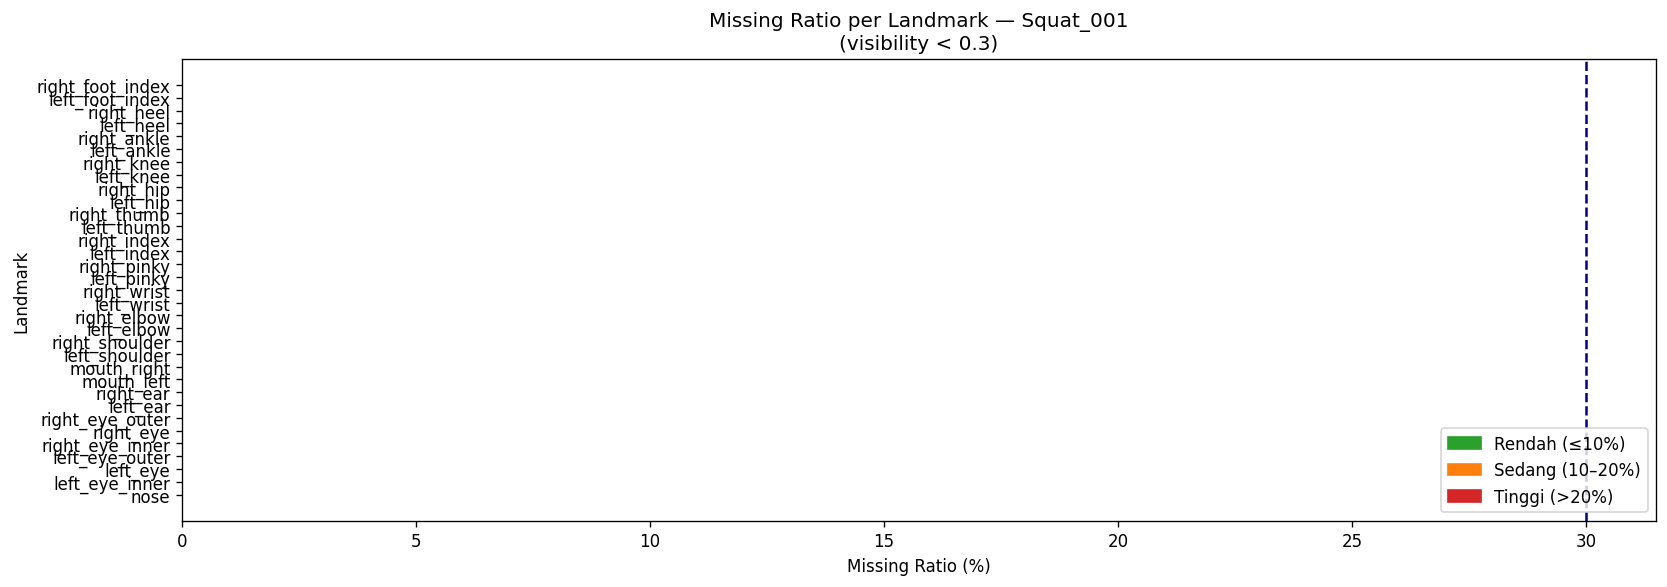


Top 10 landmark paling sering hilang:


,landmark_index,landmark_name,missing_ratio,missing_pct
0,0,nose,0.0,0.0
1,17,left_pinky,0.0,0.0
2,31,left_foot_index,0.0,0.0
3,30,right_heel,0.0,0.0
4,29,left_heel,0.0,0.0
5,28,right_ankle,0.0,0.0
6,27,left_ankle,0.0,0.0
7,26,right_knee,0.0,0.0
8,25,left_knee,0.0,0.0
9,24,right_hip,0.0,0.0


In [9]:
if audit_df is not None:
    missing_per_lm = (
        audit_df.groupby(["landmark_index", "landmark_name"])["is_low_confidence"]
        .mean()
        .reset_index()
        .rename(columns={"is_low_confidence": "missing_ratio"})
    )
    missing_per_lm["missing_pct"] = missing_per_lm["missing_ratio"] * 100

    # ── Grafik ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = [
        "#d62728" if v > 20 else "#ff7f0e" if v > 10 else "#2ca02c"
        for v in missing_per_lm["missing_pct"]
    ]
    bars = ax.barh(
        missing_per_lm["landmark_name"],
        missing_per_lm["missing_pct"],
        color=colors,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.axvline(x=VISIBILITY_THRESHOLD * 100, color="navy", linestyle="--",
               linewidth=1.5, label=f"Threshold visibility ({VISIBILITY_THRESHOLD*100:.0f}%)")
    ax.set_xlabel("Missing Ratio (%)")
    ax.set_ylabel("Landmark")
    ax.set_title(f"Missing Ratio per Landmark — {SAMPLE_LABEL}\n"
                 f"(visibility < {VISIBILITY_THRESHOLD})")
    ax.legend()

    # Legenda warna
    green_patch  = mpatches.Patch(color="#2ca02c", label="Rendah (≤10%)")
    orange_patch = mpatches.Patch(color="#ff7f0e", label="Sedang (10–20%)")
    red_patch    = mpatches.Patch(color="#d62728", label="Tinggi (>20%)")
    ax.legend(handles=[green_patch, orange_patch, red_patch], loc="lower right")

    plt.tight_layout()
    out_path = OUTPUT_PATH / "missing_ratio_landmarks.png"
    fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    log.info("Gambar disimpan: %s", out_path)
    plt.show()
    print(f"\nTop 10 landmark paling sering hilang:")
    display(
        missing_per_lm.sort_values("missing_pct", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
else:
    print("[PERINGATAN] Grafik tidak tersedia tanpa raw keypoints.")

## 9. Heatmap Visibility (Frame × 33 Landmark)

2026-07-14 19:47:20,372 [INFO] Heatmap visibility disimpan: ..\results\data_integrity\visibility_heatmap.png


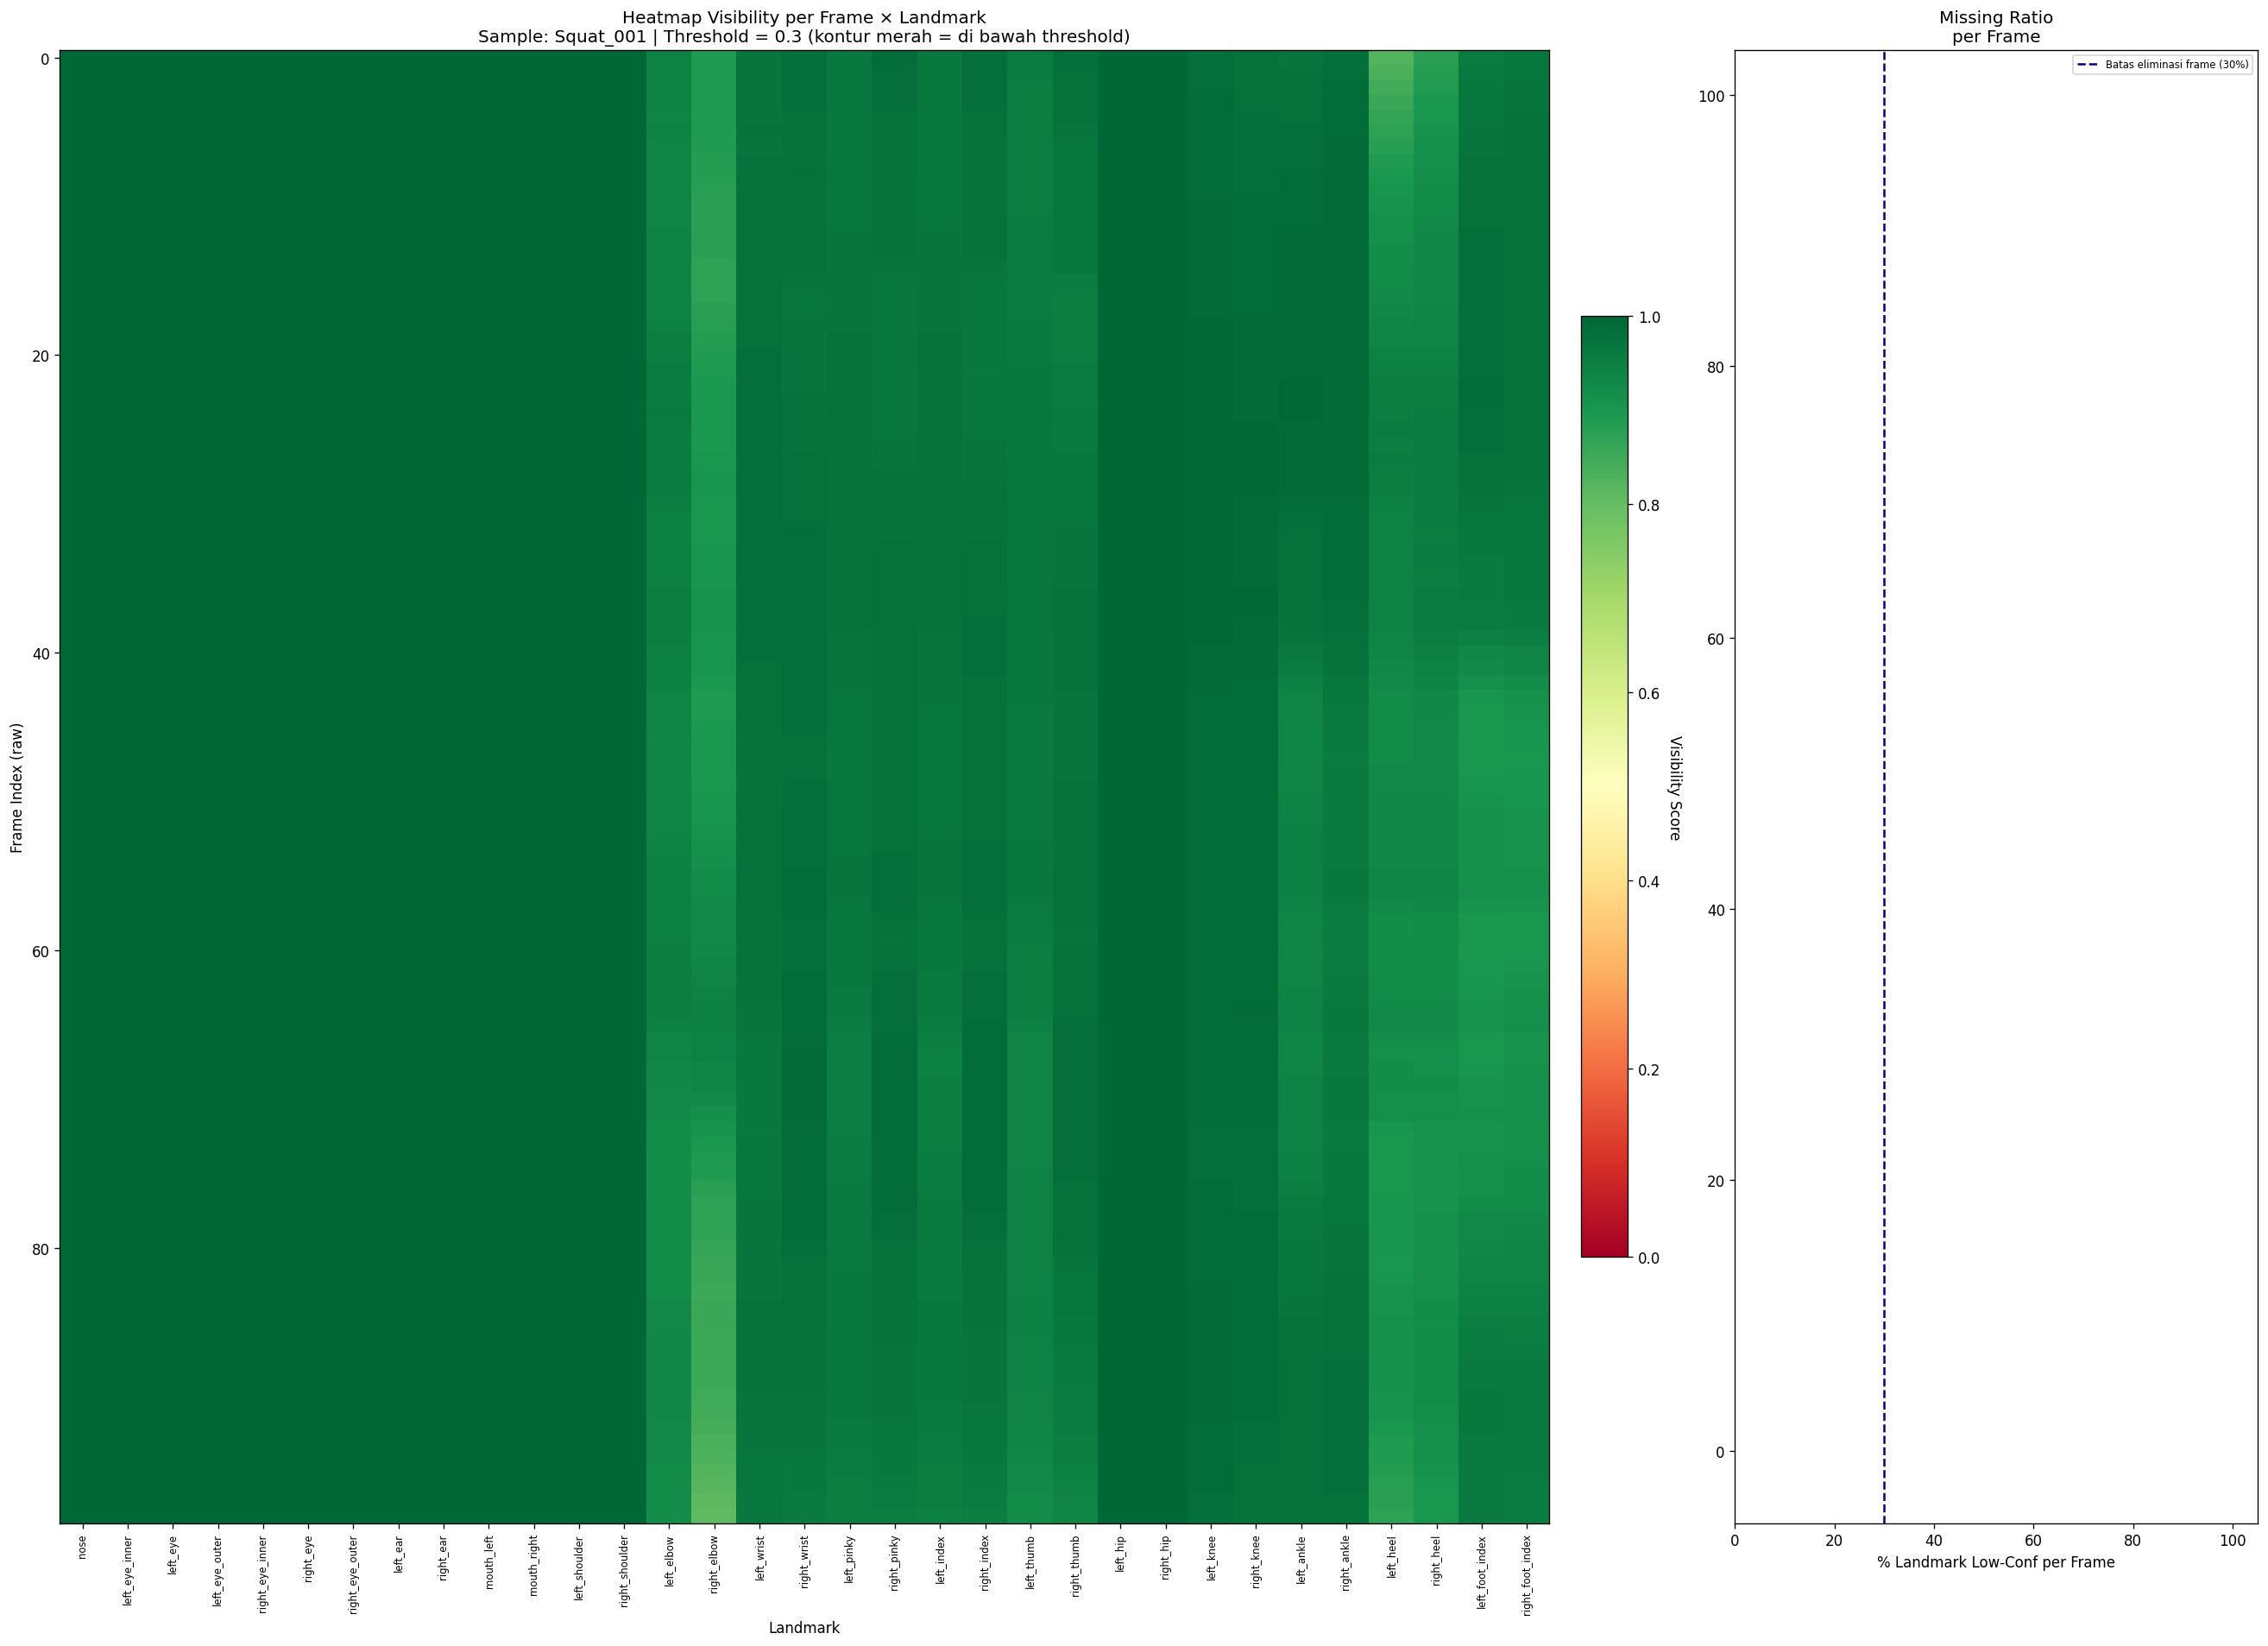

In [10]:
if raw_kp is not None:
    # Matriks visibility: (T, 33)
    vis_matrix = raw_kp[:, :, 3]  # nilai float [0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(22, max(6, raw_kp.shape[0] // 6)),
                             gridspec_kw={"width_ratios": [3, 1]})

    # ── Panel kiri: heatmap visibility ────────────────────────────────────
    ax = axes[0]
    im = ax.imshow(
        vis_matrix,
        aspect="auto",
        cmap="RdYlGn",
        vmin=0, vmax=1,
        interpolation="nearest",
    )
    ax.axhline(y=-0.5, color="white", linewidth=0)
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Visibility Score", rotation=270, labelpad=15)

    # Garis threshold
    ax.contour(
        vis_matrix < VISIBILITY_THRESHOLD,
        levels=[0.5],
        colors=["red"],
        linewidths=0.4,
    )

    ax.set_xticks(range(33))
    ax.set_xticklabels(LANDMARK_NAMES, rotation=90, fontsize=7)
    ax.set_xlabel("Landmark")
    ax.set_ylabel("Frame Index (raw)")
    ax.set_title(f"Heatmap Visibility per Frame × Landmark\n"
                 f"Sample: {SAMPLE_LABEL} | Threshold = {VISIBILITY_THRESHOLD} (kontur merah = di bawah threshold)")

    # ── Panel kanan: missing ratio per frame ──────────────────────────────
    ax2 = axes[1]
    missing_per_frame = (vis_matrix < VISIBILITY_THRESHOLD).mean(axis=1) * 100  # (T,)
    ax2.barh(
        range(raw_kp.shape[0]),
        missing_per_frame,
        color=[
            "#d62728" if v > NAN_FRAME_RATIO * 100 else "#2ca02c"
            for v in missing_per_frame
        ],
        height=0.8,
    )
    ax2.axvline(x=NAN_FRAME_RATIO * 100, color="navy", linestyle="--",
                linewidth=1.5, label=f"Batas eliminasi frame ({NAN_FRAME_RATIO*100:.0f}%)")
    ax2.set_xlim(0, 105)
    ax2.set_xlabel("% Landmark Low-Conf per Frame")
    ax2.set_title("Missing Ratio\nper Frame")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    out_path = OUTPUT_PATH / "visibility_heatmap.png"
    fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    log.info("Heatmap visibility disimpan: %s", out_path)
    plt.show()
else:
    print("[PERINGATAN] Heatmap tidak tersedia tanpa raw keypoints.")

## 10. Overlay Skeleton pada 3 Frame (Awal, Tengah, Akhir)

2026-07-14 19:47:23,911 [INFO] Frame overlay disimpan: ..\results\data_integrity\frame_overlays\Squat_001_frame_overlays.png


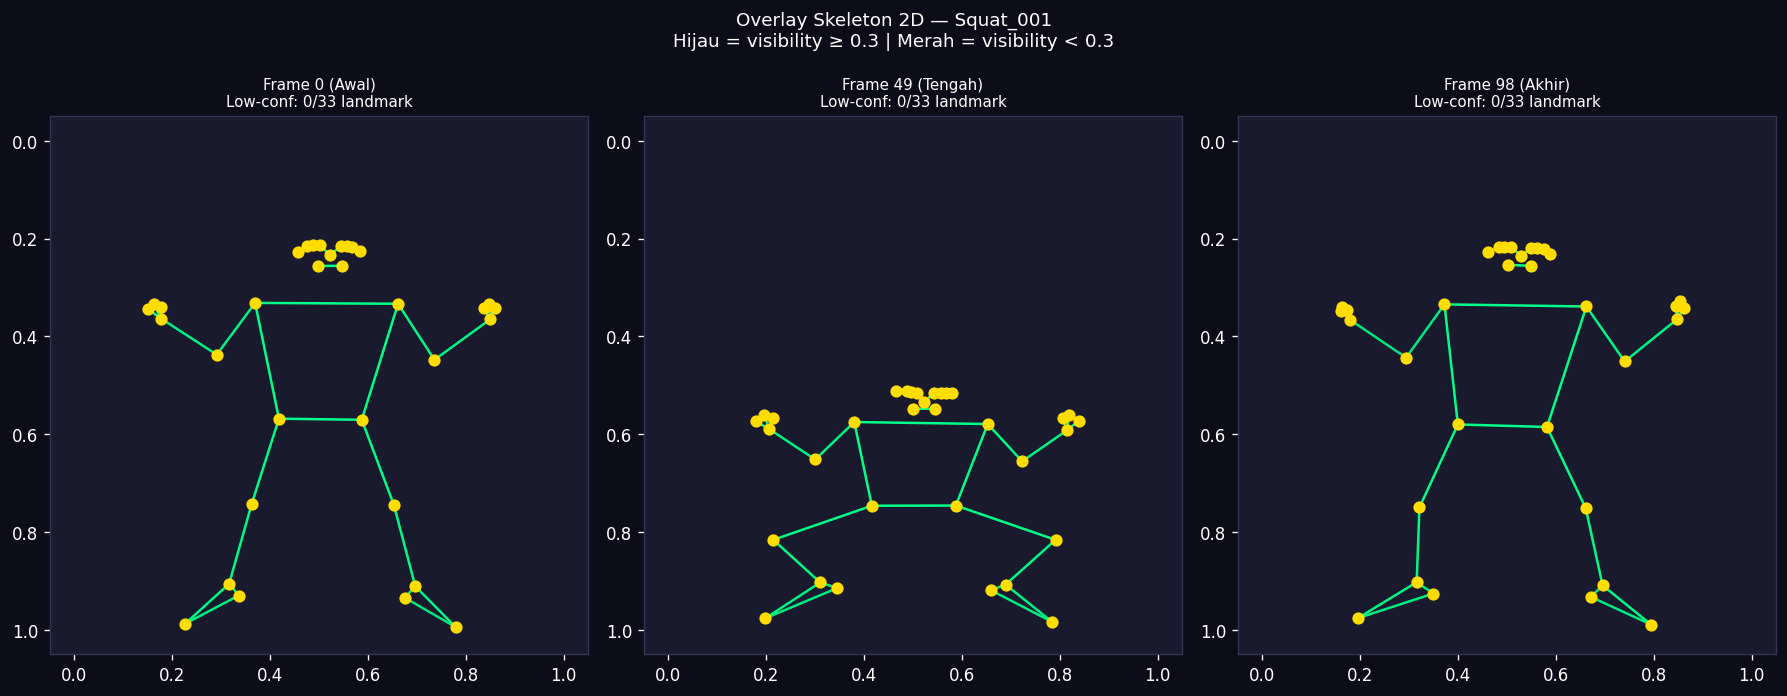

In [11]:
# Koneksi skeleton MediaPipe BlazePose untuk visualisasi 2D
POSE_CONNECTIONS: list[tuple[int, int]] = [
    # Wajah
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    # Torso
    (11, 12), (11, 23), (12, 24), (23, 24),
    # Lengan kiri
    (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),
    (17, 19),
    # Lengan kanan
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),
    (18, 20),
    # Kaki kiri
    (23, 25), (25, 27), (27, 29), (27, 31), (29, 31),
    # Kaki kanan
    (24, 26), (26, 28), (28, 30), (28, 32), (30, 32),
]


def plot_skeleton_frame(
    ax: plt.Axes,
    keypoints_frame: np.ndarray,
    vis_frame: np.ndarray,
    frame_idx: int,
    visibility_threshold: float,
    title_suffix: str = "",
) -> None:
    """
    Gambar overlay skeleton 2D (x, y) pada sebuah Axes.

    Args:
        ax               : Matplotlib Axes.
        keypoints_frame  : (33, 4) — koordinat satu frame.
        vis_frame        : (33,)   — nilai visibility satu frame.
        frame_idx        : Nomor frame (untuk label).
        visibility_threshold: Threshold confidence.
        title_suffix     : Teks tambahan pada judul.
    """
    ax.set_facecolor("#1a1a2e")

    x = keypoints_frame[:, 0]
    y = keypoints_frame[:, 1]

    # Gambar koneksi skeleton
    for (a, b) in POSE_CONNECTIONS:
        vis_a = vis_frame[a]
        vis_b = vis_frame[b]
        color = "#00ff88" if (vis_a >= visibility_threshold and vis_b >= visibility_threshold) else "#ff4444"
        alpha = max(0.3, min(1.0, (vis_a + vis_b) / 2))
        ax.plot([x[a], x[b]], [y[a], y[b]], color=color, linewidth=1.5, alpha=alpha)

    # Gambar titik landmark
    for i in range(33):
        if vis_frame[i] >= visibility_threshold:
            dot_color = "#ffdd00"
            dot_size  = 40
        else:
            dot_color = "#ff4444"
            dot_size  = 25
        ax.scatter(x[i], y[i], c=dot_color, s=dot_size, zorder=5)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(1.05, -0.05)  # Flip Y karena koordinat MediaPipe dari atas
    ax.set_aspect("equal")
    ax.set_title(
        f"Frame {frame_idx} {title_suffix}\n"
        f"Low-conf: {int((vis_frame < visibility_threshold).sum())}/33 landmark",
        color="white", fontsize=9
    )
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333355")


if raw_kp is not None:
    T_raw = raw_kp.shape[0]
    frame_indices = [
        0,
        T_raw // 2,
        T_raw - 1,
    ]
    frame_labels = ["(Awal)", "(Tengah)", "(Akhir)"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor="#0d0d1a")
    fig.suptitle(
        f"Overlay Skeleton 2D — {SAMPLE_LABEL}\n"
        f"Hijau = visibility ≥ {VISIBILITY_THRESHOLD} | Merah = visibility < {VISIBILITY_THRESHOLD}",
        color="white", fontsize=11,
    )

    for ax, fidx, flabel in zip(axes, frame_indices, frame_labels):
        plot_skeleton_frame(
            ax=ax,
            keypoints_frame=raw_kp[fidx],
            vis_frame=raw_kp[fidx, :, 3],
            frame_idx=fidx,
            visibility_threshold=VISIBILITY_THRESHOLD,
            title_suffix=flabel,
        )

    plt.tight_layout()
    out_path = FRAME_OVERLAY_DIR / f"{SAMPLE_LABEL}_frame_overlays.png"
    fig.savefig(str(out_path), dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    log.info("Frame overlay disimpan: %s", out_path)
    plt.show()
else:
    print("[PERINGATAN] Overlay skeleton tidak tersedia tanpa raw keypoints.")

## 11. Deteksi dan Visualisasi Frame Lateral (Occlusion Tinggi)

In [12]:
if raw_kp is not None:
    # Hitung jumlah landmark low-confidence per frame
    low_conf_per_frame = (raw_kp[:, :, 3] < VISIBILITY_THRESHOLD).sum(axis=1)  # (T,)

    # Frame dengan occlusion tertinggi (top 3)
    top_occ_indices = np.argsort(low_conf_per_frame)[::-1][:3]
    has_high_occlusion = low_conf_per_frame[top_occ_indices[0]] > 5

    if has_high_occlusion:
        fig, axes = plt.subplots(1, len(top_occ_indices),
                                  figsize=(5 * len(top_occ_indices), 6),
                                  facecolor="#0d0d1a")
        if len(top_occ_indices) == 1:
            axes = [axes]

        fig.suptitle(
            f"Frame dengan Occlusion Tertinggi — {SAMPLE_LABEL}\n"
            "(kemungkinan sudut lateral atau postur ekstrem)",
            color="white", fontsize=11,
        )

        for ax, fidx in zip(axes, top_occ_indices):
            n_low = int(low_conf_per_frame[fidx])
            plot_skeleton_frame(
                ax=ax,
                keypoints_frame=raw_kp[fidx],
                vis_frame=raw_kp[fidx, :, 3],
                frame_idx=int(fidx),
                visibility_threshold=VISIBILITY_THRESHOLD,
                title_suffix=f"— {n_low} landmark low-conf",
            )

        plt.tight_layout()
        out_path = FRAME_OVERLAY_DIR / f"{SAMPLE_LABEL}_high_occlusion_frames.png"
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        log.info("Frame high-occlusion disimpan: %s", out_path)
        plt.show()

        print(f"\nFrame dengan occlusion tertinggi:")
        for fidx in top_occ_indices:
            names = [LANDMARK_NAMES[i] for i in range(33)
                     if raw_kp[fidx, i, 3] < VISIBILITY_THRESHOLD]
            print(f"  Frame {fidx:4d}: {int(low_conf_per_frame[fidx]):2d} landmark low-conf → {names}")
    else:
        print("[INFO] Tidak ada frame dengan occlusion tinggi yang signifikan (>5 landmark).")
        print("       Ini adalah indikasi kualitas video yang baik.")
else:
    print("[PERINGATAN] Tidak tersedia tanpa raw keypoints.")

[INFO] Tidak ada frame dengan occlusion tinggi yang signifikan (>5 landmark).
       Ini adalah indikasi kualitas video yang baik.


## 12. Verifikasi 33 Landmark pada Setiap Frame Tensor Final

In [13]:
if final_tensor is not None:
    print("\n" + "=" * 60)
    print("PEMBUKTIAN FORMAL: 33 LANDMARK PADA SETIAP FRAME")
    print("=" * 60)

    n_frames_final, n_lm_final, n_coords_final = final_tensor.shape

    # Assertion 1: 64 frame
    assert n_frames_final == TARGET_FRAMES, (
        f"[GAGAL] Jumlah frame: {n_frames_final} ≠ {TARGET_FRAMES}"
    )
    print(f"  [OK] Jumlah frame  : {n_frames_final} = {TARGET_FRAMES} ✓")

    # Assertion 2: 33 landmark per frame
    assert n_lm_final == N_LANDMARKS, (
        f"[GAGAL] Jumlah landmark: {n_lm_final} ≠ {N_LANDMARKS}"
    )
    print(f"  [OK] Landmark/frame: {n_lm_final} = {N_LANDMARKS} ✓")

    # Assertion 3: 3 koordinat
    assert n_coords_final == 3, (
        f"[GAGAL] Dimensi koordinat: {n_coords_final} ≠ 3"
    )
    print(f"  [OK] Koordinat/lm  : {n_coords_final} = 3 (x, y, z) ✓")

    # Verifikasi per-frame bahwa tidak ada frame yang kehilangan landmark
    n_lm_per_frame = np.array([
        final_tensor[f, :, :].shape[0] for f in range(n_frames_final)
    ])
    assert (n_lm_per_frame == N_LANDMARKS).all(), (
        "[GAGAL] Ada frame dengan jumlah landmark tidak tepat 33!"
    )
    print(f"  [OK] Semua {n_frames_final} frame memiliki tepat 33 landmark ✓")

    # Statistik distribusi koordinat per dimensi
    print("\nStatistik koordinat tensor final:")
    dim_labels = ["x", "y", "z"]
    stats_rows = []
    for dim_i, dim_label in enumerate(dim_labels):
        vals = final_tensor[:, :, dim_i].flatten()
        stats_rows.append({
            "dimensi": dim_label,
            "min"    : round(float(vals.min()), 4),
            "max"    : round(float(vals.max()), 4),
            "mean"   : round(float(vals.mean()), 4),
            "std"    : round(float(vals.std()), 4),
            "n_zero" : int((vals == 0).sum()),
        })
    display(pd.DataFrame(stats_rows))

    print("\n" + "=" * 60)
    print("KESIMPULAN: Tensor input model (64, 33, 3) telah TERVERIFIKASI.")
    print("  Setiap frame memiliki tepat 33 landmark BlazePose.")
    print("  Tidak ada NaN atau Inf.")
    print("=" * 60)
else:
    print("[PERINGATAN] Tensor final tidak tersedia untuk verifikasi formal.")


PEMBUKTIAN FORMAL: 33 LANDMARK PADA SETIAP FRAME
  [OK] Jumlah frame  : 64 = 64 ✓
  [OK] Landmark/frame: 33 = 33 ✓
  [OK] Koordinat/lm  : 3 = 3 (x, y, z) ✓
  [OK] Semua 64 frame memiliki tepat 33 landmark ✓

Statistik koordinat tensor final:


,dimensi,min,max,mean,std,n_zero
0,x,-1.7672,1.8607,0.0424,0.8039,0
1,y,-1.4888,1.7526,-0.3840,0.8621,0
2,z,-4.9622,2.7617,-1.0016,1.6307,0



KESIMPULAN: Tensor input model (64, 33, 3) telah TERVERIFIKASI.
  Setiap frame memiliki tepat 33 landmark BlazePose.
  Tidak ada NaN atau Inf.


## 13. Visualisasi Tensor Final (64 Frame Ternormalisasi)

2026-07-14 19:47:26,984 [INFO] Heatmap tensor final disimpan: ..\results\data_integrity\frame_overlays\Squat_001_final_tensor_heatmap.png


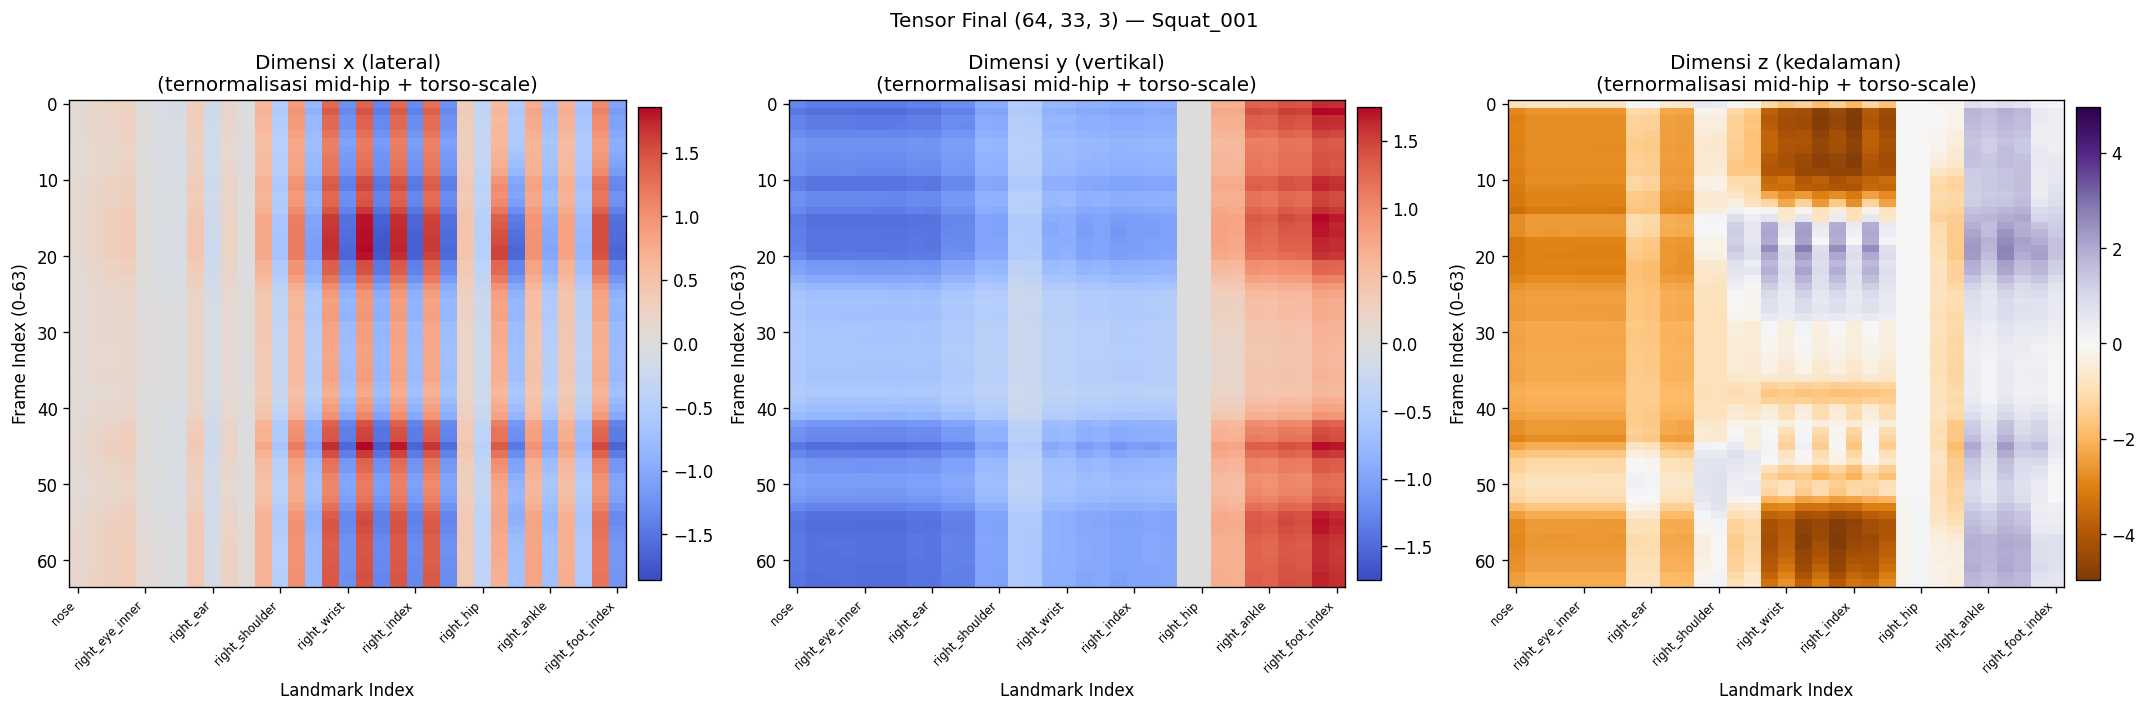

In [14]:
if final_tensor is not None:
    # Heatmap intensitas nilai per frame × landmark (dimensi x saja sebagai representasi)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    dim_labels = ["x (lateral)", "y (vertikal)", "z (kedalaman)"]
    cmaps = ["coolwarm", "coolwarm", "PuOr"]

    for dim_i, (ax, dlabel, cmap) in enumerate(zip(axes, dim_labels, cmaps)):
        data_2d = final_tensor[:, :, dim_i]  # (64, 33)
        vabs = np.abs(data_2d).max()
        im = ax.imshow(
            data_2d,
            aspect="auto",
            cmap=cmap,
            vmin=-vabs,
            vmax=vabs,
            interpolation="nearest",
        )
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        ax.set_xticks(range(0, 33, 4))
        ax.set_xticklabels([LANDMARK_NAMES[i] for i in range(0, 33, 4)], rotation=45, ha="right", fontsize=7)
        ax.set_xlabel("Landmark Index")
        ax.set_ylabel("Frame Index (0–63)")
        ax.set_title(f"Dimensi {dlabel}\n(ternormalisasi mid-hip + torso-scale)")

    fig.suptitle(f"Tensor Final (64, 33, 3) — {SAMPLE_LABEL}", fontsize=12)
    plt.tight_layout()
    out_path = FRAME_OVERLAY_DIR / f"{SAMPLE_LABEL}_final_tensor_heatmap.png"
    fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    log.info("Heatmap tensor final disimpan: %s", out_path)
    plt.show()
else:
    print("[PERINGATAN] Tensor final tidak tersedia.")

## 14. Simpan Laporan CSV

In [15]:
def save_integrity_report(
    audit_df: Optional[pd.DataFrame],
    summary_stats: Optional[pd.DataFrame],
    validation_result: dict,
    output_path: Path,
    sample_label: str,
) -> None:
    """
    Simpan laporan integritas ke file CSV.
    """
    # ── Tabel audit lengkap ────────────────────────────────────────────────
    if audit_df is not None:
        csv_path = output_path / "sample_integrity_report.csv"
        audit_df.to_csv(str(csv_path), index=False, encoding="utf-8")
        log.info("Laporan audit disimpan: %s (%d baris)", csv_path, len(audit_df))
        print(f"[OK] Tabel audit → {csv_path}")

    # ── Statistik ringkasan ────────────────────────────────────────────────
    if summary_stats is not None:
        stats_path = output_path / f"{sample_label}_summary_stats.csv"
        summary_stats.to_csv(str(stats_path), encoding="utf-8")
        log.info("Statistik ringkasan disimpan: %s", stats_path)
        print(f"[OK] Statistik ringkasan → {stats_path}")

    # ── Hasil validasi ─────────────────────────────────────────────────────
    val_path = output_path / f"{sample_label}_validation_result.csv"
    pd.Series(validation_result).to_csv(str(val_path), encoding="utf-8",
                                         header=["value"])
    log.info("Hasil validasi disimpan: %s", val_path)
    print(f"[OK] Hasil validasi → {val_path}")


save_integrity_report(
    audit_df=audit_df,
    summary_stats=summary_stats,
    validation_result=validation_result,
    output_path=OUTPUT_PATH,
    sample_label=SAMPLE_LABEL,
)
print("\nSemua output tersimpan di:", OUTPUT_PATH.resolve())

2026-07-14 19:47:27,679 [INFO] Laporan audit disimpan: ..\results\data_integrity\sample_integrity_report.csv (3267 baris)
[OK] Tabel audit → ..\results\data_integrity\sample_integrity_report.csv
2026-07-14 19:47:27,679 [INFO] Statistik ringkasan disimpan: ..\results\data_integrity\Squat_001_summary_stats.csv
[OK] Statistik ringkasan → ..\results\data_integrity\Squat_001_summary_stats.csv
2026-07-14 19:47:27,695 [INFO] Hasil validasi disimpan: ..\results\data_integrity\Squat_001_validation_result.csv
[OK] Hasil validasi → ..\results\data_integrity\Squat_001_validation_result.csv

Semua output tersimpan di: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\data_integrity


## 15. Ringkasan Akhir & Kesimpulan Audit

In [16]:
print("\n" + "#" * 70)
print("  RINGKASAN AUDIT INTEGRITAS DATA SKELETON")
print("  Proyek: AttentiveSkel3D — Weight Training Form Assessment")
print(f"  Sampel: {SAMPLE_LABEL}")
print("#" * 70)

if raw_kp is not None:
    T_raw = raw_kp.shape[0]
    low_conf_total = int((raw_kp[:, :, 3] < VISIBILITY_THRESHOLD).sum())
    total_obs = T_raw * N_LANDMARKS
    print(f"\n  FASE EKSTRAKSI")
    print(f"  ├─ Frame raw terdeteksi     : {T_raw}")
    print(f"  ├─ Landmark per frame        : {N_LANDMARKS}")
    print(f"  ├─ Total observasi           : {total_obs}")
    print(f"  └─ Low-confidence (vis<{VISIBILITY_THRESHOLD}): {low_conf_total} ({low_conf_total/total_obs*100:.1f}%)")

    if audit_df is not None:
        n_frame_removed = audit_df[
            audit_df["interpolation_status"] == "frame_removed"
        ]["frame_index"].nunique()
        n_interp = (audit_df["interpolation_status"] == "interpolated").sum()
        n_zerofill = (audit_df["interpolation_status"] == "zero_fill").sum()
        print(f"\n  FASE PEMBERSIHAN (filter_and_clean)")
        print(f"  ├─ Threshold visibility      : {VISIBILITY_THRESHOLD}")
        print(f"  ├─ Max NaN ratio per frame   : {NAN_FRAME_RATIO*100:.0f}%")
        print(f"  ├─ Frame dieliminasi         : {n_frame_removed} ({n_frame_removed/T_raw*100:.1f}%)")
        print(f"  ├─ Nilai diinterpolasi       : {n_interp}")
        print(f"  └─ Nilai zero-fill fallback  : {n_zerofill}")

if final_tensor is not None:
    print(f"\n  TENSOR FINAL")
    print(f"  ├─ Shape                     : {final_tensor.shape}  ← (64, 33, 3) ✓")
    print(f"  ├─ Jumlah NaN                : {int(np.isnan(final_tensor).sum())} ✓")
    print(f"  ├─ Jumlah Inf                : {int(np.isinf(final_tensor).sum())} ✓")
    print(f"  └─ Status validasi           : {validation_result.get('status', 'N/A')}")

print(f"\n  OUTPUT TERSIMPAN")
print(f"  ├─ {OUTPUT_PATH / 'sample_integrity_report.csv'}")
print(f"  ├─ {OUTPUT_PATH / 'visibility_heatmap.png'}")
print(f"  ├─ {OUTPUT_PATH / 'missing_ratio_landmarks.png'}")
print(f"  └─ {FRAME_OVERLAY_DIR}/")
print("\n" + "#" * 70)
print("  AUDIT SELESAI")
print("#" * 70)


######################################################################
  RINGKASAN AUDIT INTEGRITAS DATA SKELETON
  Proyek: AttentiveSkel3D — Weight Training Form Assessment
  Sampel: Squat_001
######################################################################

  FASE EKSTRAKSI
  ├─ Frame raw terdeteksi     : 99
  ├─ Landmark per frame        : 33
  ├─ Total observasi           : 3267
  └─ Low-confidence (vis<0.3): 0 (0.0%)

  FASE PEMBERSIHAN (filter_and_clean)
  ├─ Threshold visibility      : 0.3
  ├─ Max NaN ratio per frame   : 30%
  ├─ Frame dieliminasi         : 0 (0.0%)
  ├─ Nilai diinterpolasi       : 0
  └─ Nilai zero-fill fallback  : 0

  TENSOR FINAL
  ├─ Shape                     : (64, 33, 3)  ← (64, 33, 3) ✓
  ├─ Jumlah NaN                : 0 ✓
  ├─ Jumlah Inf                : 0 ✓
  └─ Status validasi           : LULUS

  OUTPUT TERSIMPAN
  ├─ ..\results\data_integrity\sample_integrity_report.csv
  ├─ ..\results\data_integrity\visibility_heatmap.png
  ├─ ..\results\da

---

## Appendix: Audit Batch pada Seluruh Tensor Final

Cell opsional di bawah menjalankan validasi shape, NaN, dan Inf pada **semua** tensor final dalam direktori `data/processed/tensors/`.

In [17]:
# =============================================================================
# OPSIONAL: Jalankan cell ini untuk audit batch semua tensor
# =============================================================================

TENSOR_DIR = PROJECT_ROOT / "data" / "processed" / "tensors"

if not TENSOR_DIR.exists():
    print(f"[SKIP] Direktori tensor tidak ditemukan: {TENSOR_DIR}")
else:
    npy_files = sorted(TENSOR_DIR.glob("*.npy"))
    log.info("Memulai audit batch: %d file tensor", len(npy_files))

    batch_results: list[dict] = []
    n_fail = 0

    for npy_file in npy_files:
        try:
            t = np.load(str(npy_file)).astype(np.float32)
            shape_ok = t.shape == (TARGET_FRAMES, N_LANDMARKS, 3)
            nan_ok   = not np.isnan(t).any()
            inf_ok   = not np.isinf(t).any()
            passed   = shape_ok and nan_ok and inf_ok
            if not passed:
                n_fail += 1
            batch_results.append({
                "file"       : npy_file.name,
                "shape"      : str(t.shape),
                "shape_ok"   : shape_ok,
                "n_nan"      : int(np.isnan(t).sum()),
                "n_inf"      : int(np.isinf(t).sum()),
                "passed"     : passed,
            })
        except Exception as exc:
            n_fail += 1
            batch_results.append({
                "file"    : npy_file.name,
                "shape"   : "ERROR",
                "shape_ok": False,
                "n_nan"   : -1,
                "n_inf"   : -1,
                "passed"  : False,
            })
            log.error("Error saat memuat %s: %s", npy_file.name, exc)

    batch_df = pd.DataFrame(batch_results)
    n_total  = len(batch_df)
    n_pass   = int(batch_df["passed"].sum())

    print(f"\n{'=' * 60}")
    print(f"AUDIT BATCH — {TENSOR_DIR}")
    print(f"{'=' * 60}")
    print(f"Total tensor   : {n_total}")
    print(f"Lulus validasi : {n_pass} ({n_pass/n_total*100:.1f}%)")
    print(f"Gagal validasi : {n_fail} ({n_fail/n_total*100:.1f}%)")
    print(f"{'=' * 60}")

    if n_fail > 0:
        print("\nTensor yang GAGAL validasi:")
        display(batch_df[~batch_df["passed"]])
    else:
        print("\n[OK] Semua tensor lulus validasi (64, 33, 3) tanpa NaN/Inf.")

    # Simpan hasil audit batch
    batch_csv = OUTPUT_PATH / "batch_tensor_validation.csv"
    batch_df.to_csv(str(batch_csv), index=False, encoding="utf-8")
    log.info("Hasil audit batch disimpan: %s", batch_csv)
    print(f"\nHasil batch disimpan → {batch_csv}")

    # Ringkasan per exercise class
    batch_df["exercise"] = batch_df["file"].str.extract(r"^([A-Za-z]+)")
    summary_by_class = batch_df.groupby("exercise")["passed"].agg(["sum", "count"])
    summary_by_class.columns = ["lulus", "total"]
    summary_by_class["pct_lulus"] = (summary_by_class["lulus"] / summary_by_class["total"] * 100).round(1)
    print("\nRingkasan per kelas latihan:")
    display(summary_by_class)

2026-07-14 19:47:27,769 [INFO] Memulai audit batch: 487 file tensor

AUDIT BATCH — G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\data\processed\tensors
Total tensor   : 487
Lulus validasi : 487 (100.0%)
Gagal validasi : 0 (0.0%)

[OK] Semua tensor lulus validasi (64, 33, 3) tanpa NaN/Inf.
2026-07-14 19:47:35,049 [INFO] Hasil audit batch disimpan: ..\results\data_integrity\batch_tensor_validation.csv

Hasil batch disimpan → ..\results\data_integrity\batch_tensor_validation.csv

Ringkasan per kelas latihan:


,lulus,total,pct_lulus
exercise,,,
BenchPress,187,187,100.0
Deadlift,129,129,100.0
Squat,171,171,100.0
